In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Drive connected!")

Mounted at /content/drive
Drive connected!


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Point to your Google Drive folder
DATA_DIR = '/content/drive/MyDrive/lung_cancer_cnn'

# Check folders are found (skip any files like .txt)
for item in os.listdir(DATA_DIR):
    item_path = os.path.join(DATA_DIR, item)
    if os.path.isdir(item_path):  # only process folders
        count = len(os.listdir(item_path))
        print(f"{item}: {count} images")
    else:
        print(f"Skipping file: {item}")

Skipping file: IQ-OTH_NCCD lung cancer dataset.txt
Bengin cases: 120 images
Malignant cases: 561 images
Normal cases: 416 images
Skipping file: cnn_model_final.h5


In [ ]:
IMG_SIZE = (128, 128)   # updated to match model
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,    # slight shift
    height_shift_range=0.1,   # slight shift
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Classes:", train_data.class_indices)
print("Training images:", train_data.samples)
print("Validation images:", val_data.samples)

Found 878 images belonging to 3 classes.
Found 219 images belonging to 3 classes.
Classes: {'Bengin cases': 0, 'Malignant cases': 1, 'Normal cases': 2}
Training images: 878
Validation images: 219


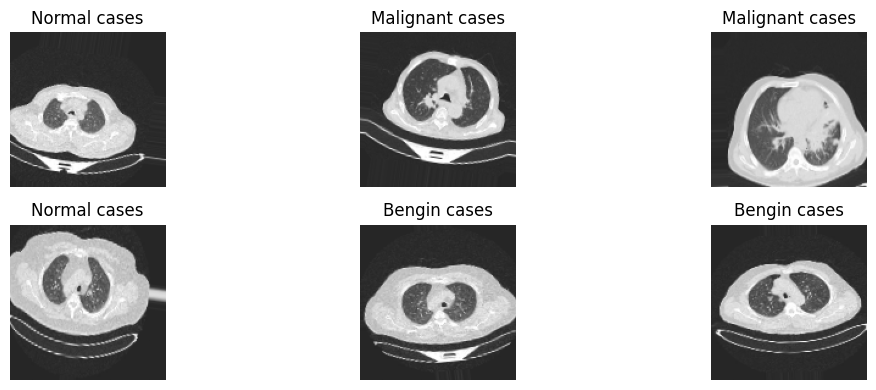

In [ ]:
# See what the images look like
images, labels = next(train_data)
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(12, 4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(128, 128, 3),   # slightly bigger = more detail
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

# Stronger classifier on top
inputs = keras.Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)     # stabilizes training
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # smaller lr = stable
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model built ✅")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model built ✅


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,811 (9.89 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Fix class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Callbacks — smart training helpers
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,              # stop if no improvement for 5 epochs
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # halve learning rate when stuck
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Train
EPOCHS = 25   # more epochs, but early stop will kick in

history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],   # smart helpers
    verbose=1
)

print(f"\nFinal train accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final val accuracy:   {history.history['val_accuracy'][-1]*100:.2f}%")

Class weights: {0: np.float64(3.048611111111111), 1: np.float64(0.651818856718634), 2: np.float64(0.8788788788788788)}
Epoch 1/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 730s 25s/step - accuracy: 0.4305 - loss: 1.4084 - val_accuracy: 0.6438 - val_loss: 0.8122 - learning_rate: 1.0000e-04
Epoch 2/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 427ms/step - accuracy: 0.6572 - loss: 0.8738 - val_accuracy: 0.6530 - val_loss: 0.7677 - learning_rate: 1.0000e-04
Epoch 3/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 441ms/step - accuracy: 0.6970 - loss: 0.7595 - val_accuracy: 0.6621 - val_loss: 0.7636 - learning_rate: 1.0000e-04
Epoch 4/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 447ms/step - accuracy: 0.7517 - loss: 0.6877 - val_accuracy: 0.6621 - val_loss: 0.7598 - learning_rate: 1.0000e-04
Epoch 5/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 437ms/step - accuracy: 0.7380 - loss: 0.6734 - val_accuracy: 0.6484 - val_loss: 0.8158 - learning_rate: 1.0000e-04
Epoch 6/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 425ms/step - accuracy: 0.7825 - loss: 0.5820 - val_accu

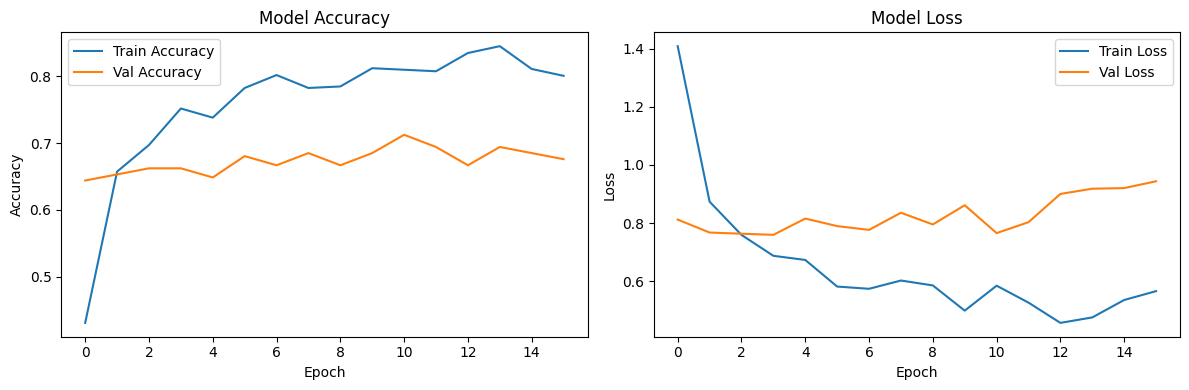

In [ ]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save model RIGHT AFTER training
model.save('/content/drive/MyDrive/lung_cancer_cnn/cnn_model_final.h5')
print("Model saved to Google Drive")

# Confirm it saved
import os
path = '/content/drive/MyDrive/lung_cancer_cnn/cnn_model_final.h5'
if os.path.exists(path):
    size = os.path.getsize(path) / (1024*1024)
    print(f"File confirmed: {size:.1f} MB")
else:
    print("Save failed — try again!")

Model saved to Google Drive
File confirmed: 12.8 MB


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Find a sample image automatically
malignant_folder = '/content/drive/MyDrive/lung_cancer_cnn/Malignant cases'
sample_image_name = os.listdir(malignant_folder)[0]
sample_image_path = os.path.join(malignant_folder, sample_image_name)
print(f"Testing with: {sample_image_name}")

# Predict function
def predict_ct_scan(img_path):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_names = ['Benign', 'Malignant', 'Normal']

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    print(f"\nPrediction  : {predicted_class}")
    print(f"Confidence  : {confidence:.2f}%")
    print(f"\nAll probabilities:")
    for name, prob in zip(class_names, prediction[0]):
        print(f"  {name}: {prob*100:.2f}%")

# Run prediction
predict_ct_scan(sample_image_path)

Testing with: Malignant case (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step

Prediction  : Malignant
Confidence  : 98.40%

All probabilities:
  Benign: 1.58%
  Malignant: 98.40%
  Normal: 0.01%


In [ ]:
# Save in new format — works across all TF versions
model.save('/content/drive/MyDrive/lung_cancer_cnn/cnn_model_final.keras')
print("Saved in .keras format")

# Also download directly
from google.colab import files
files.download('/content/drive/MyDrive/lung_cancer_cnn/cnn_model_final.keras')

Saved in .keras format


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save ONLY the weights (no architecture — avoids version issues)
model.save_weights('/content/drive/MyDrive/lung_cancer_cnn/cnn_weights.weights.h5')
print("Weights saved ✅")

from google.colab import files
files.download('/content/drive/MyDrive/lung_cancer_cnn/cnn_weights.weights.h5')

Weights saved ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>